# Image Model with Logit Loss Function


# Table of Contents
1. [Loading Data](#Loading-Data)
2. [Labels](#Labels)
3. [Data Processing](#Data-Processing)
4. [Building Model](#Building-Model)
5. [Visualizations](#visualizations)
6. [Evaluation](#Evaluation)

## Loading Data

In [1]:
import pandas as pd
import zipfile
import chardet
import io

zip_path = 'v2_combined-20260406T063631Z-1-001.zip'

data_dict = {}

with zipfile.ZipFile(zip_path, 'r') as z:
    # Get list of all files in the zip
    files = z.namelist()
    
    for file_name in files:
        if file_name.endswith('.csv'):
            with z.open(file_name) as f:
                
                raw_data = f.read(20000) 
                result = chardet.detect(raw_data)
                enc = result['encoding']
                
               
                f.seek(0)
                print(f"Loading {file_name} with detected encoding: {enc}")
                
                try:
                   
                    data_dict[file_name] = pd.read_csv(f, encoding=enc)
                except Exception as e:
                    print(f"Failed with {enc}, trying 'latin1' fallback for {file_name}")
                    f.seek(0)
                    data_dict[file_name] = pd.read_csv(f, encoding='latin1')


print("\nSuccessfully loaded DataFrames:", list(data_dict.keys()))

Loading v2_combined/data_chunk_4.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_1.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_0.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_6.csv with detected encoding: utf-8
Loading v2_combined/Reviews/reviews_chunk_14.csv with detected encoding: ascii
Failed with ascii, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_14.csv
Loading v2_combined/Reviews/reviews_chunk_10.csv with detected encoding: ascii
Failed with ascii, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_10.csv
Loading v2_combined/Reviews/reviews_chunk_3.csv with detected encoding: Windows-1252
Failed with Windows-1252, trying 'latin1' fallback for v2_combined/Reviews/reviews_chunk_3.csv
Loading v2_combined/data_chunk_7.csv with detected encoding: utf-8
Loading v2_combined/data_chunk_2.csv with detected encoding: utf-8
Loading v2_combined/Reviews/reviews_chunk_5.csv with detected encoding: ascii
Fail

In [2]:
data_keys = [k for k in data_dict.keys() if 'data_chunk' in k]
review_keys = [k for k in data_dict.keys() if 'reviews_chunk' in k]



df_main_data = pd.concat([data_dict[k] for k in data_keys], axis=0, ignore_index=True).drop_duplicates()


df_reviews = pd.concat([data_dict[k] for k in review_keys], axis=0, ignore_index=True).drop_duplicates()

print(f"Main Data Rows: {len(df_main_data)}")
print(f"Review Rows: {len(df_reviews)}")

Main Data Rows: 572215
Review Rows: 3794003


In [3]:
df_main_data = df_main_data.rename(columns={'RecipeId': 'recipe_id'})

In [4]:
df_main_data.columns

Index(['recipe_id', 'Name', 'RecipeInstructions', 'Images',
       'AggregatedRating_na', 'ReviewCount', 'Calories', 'FatContent',
       'SaturatedFatContent', 'CholesterolContent', 'SodiumContent',
       'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent',
       'source', 'PrepTime', 'CookTime', 'TotalTime', 'PrepTime_Minutes',
       'CookTime_Minutes', 'TotalTime_Minutes', 'RecipeIngredientParts',
       'RecipeIngredientParts_old', 'ingredients_canonical',
       'ingredients_canonical_auto', 'ingredients_canonical_final',
       'ingredients_canonical_final_le_5_replace', 'EnergyFromFat',
       'EnergyFromSaturatedFat', 'EnergyFromCarbs', 'EnergyFromProtein',
       'SaturatedFatPercentEnergy', 'FatPercentEnergy', 'WHO_SatFat_Compliant',
       'WHO_Fat_Compliant', 'WHO_Sodium_Compliant', 'WHO_Score', 'WHO_Healthy',
       'Energy_kJ', 'A_score', 'C_score', 'FSA_Score', 'FSA_Healthy',
       'popularity_score'],
      dtype='object')

In [5]:
import kagglehub

path = kagglehub.dataset_download("elisaxxygao/foodrecsysv1")
IMG_DIR = f"{path}/raw-data-images/raw-data-images"

df_kaggle_lookup = pd.read_csv(f"{path}/core-data_recipe.csv")[['recipe_id']]
df_kaggle_lookup['image_path'] = df_kaggle_lookup['recipe_id'].apply(lambda x: f"{IMG_DIR}/{x}.jpg")



final_recipe_df = pd.merge(
    df_main_data, 
    df_kaggle_lookup, 
    on='recipe_id', 
    how='inner'
)


print(f"Total recipes with images and metadata: {len(final_recipe_df)}")

Total recipes with images and metadata: 89937


## Labels

In [6]:
vocab_df  = pd.read_csv('ingredient_counts_ingredients_canonical_final_le_5_replace.csv')
label_col = vocab_df.columns[0]  # ingredients_canonical_final
vocab     = {ing: idx for idx, ing in enumerate(vocab_df[label_col])}

print(f"Vocab size: {len(vocab)}")
print(f"Top 10: {list(vocab.keys())[:10]}")

Vocab size: 5442
Top 10: ['salt', 'onion', 'sugar', 'butter', 'garlic', 'egg', 'olive oil', 'water', 'milk', 'flour']


In [7]:
import os, re, pickle, torch, requests
import torch.nn as nn
import pandas as pd
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
import kagglehub

## Data Processing

In [8]:
train_df, temp_df = train_test_split(
    final_recipe_df, 
    test_size=0.4, 
    random_state=42, 
    shuffle=True
)


val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    shuffle=True
)


print(f"Final Combined Dataset: {len(final_recipe_df)} rows")
print("-" * 30)
print(f"Train Set: {len(train_df)} rows (60%)")
print(f"Val Set:   {len(val_df)} rows (20%)")
print(f"Test Set:  {len(test_df)} rows (20%)")

Final Combined Dataset: 89937 rows
------------------------------
Train Set: 53962 rows (60%)
Val Set:   17987 rows (20%)
Test Set:  17988 rows (20%)


In [9]:
class RecipeDataset(Dataset):
    def __init__(self, df, vocab, transform=None):
        self.df        = df.reset_index(drop=True)
        self.vocab     = vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        try:
            image = Image.open(row['image_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        # Parse ingredients
        label = torch.zeros(len(self.vocab))
        try:
            ingredients = ast.literal_eval(row['ingredients_canonical_final'])
            for ing in ingredients:
                ing = ing.lower().strip()
                if ing in self.vocab:
                    label[self.vocab[ing]] = 1.0
        except:
            pass

        return image, label

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # REsnet features
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # REsnet features
])

train_loader = DataLoader(RecipeDataset(train_df, vocab, train_transform), batch_size=8, shuffle=True,  num_workers=1)
val_loader   = DataLoader(RecipeDataset(val_df,   vocab, test_transform),  batch_size=8, shuffle=False, num_workers=1)
test_loader  = DataLoader(RecipeDataset(test_df,  vocab, test_transform),  batch_size=8, shuffle=False, num_workers=1)

print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

Train: 53962 | Val: 17987 | Test: 17988


In [10]:
vocab_df

,Ingredient,Count
0,salt,207585
1,onion,147344
2,sugar,136805
3,butter,135578
4,garlic,131991
...,...,...
5437,torn arugula leaf,6
5438,olive oil flavored vegetable cooking spray,6
5439,mccormick garlic powder,6
5440,fluid ounce whiskey,6


In [11]:
import ast
# Check val labels
for images, labels in val_loader:
    print(f"Label sum per sample: {labels.sum(dim=1)[:5]}")
    print(f"Max label value: {labels.max()}")
    break


sample = val_df['ingredients_canonical_final'].iloc[0]
print(f"\nVal sample: {repr(sample)}")
parsed = ast.literal_eval(sample)
print(f"Parsed: {parsed[:3]}")

# Check matches
for ing in parsed[:5]:
    ing_clean = ing.lower().strip()
    print(f"  '{ing_clean}' in vocab: {ing_clean in vocab}")

Label sum per sample: tensor([10., 14.,  3.,  5.,  6.])
Max label value: 1.0

Val sample: "['all purpose flour', 'sugar', 'baking soda', 'salt', 'nutmeg', 'cinnamon', 'shortening', 'egg', 'banana', 'rolled oat']"
Parsed: ['all purpose flour', 'sugar', 'baking soda']
  'all purpose flour' in vocab: True
  'sugar' in vocab: True
  'baking soda' in vocab: True
  'salt' in vocab: True
  'nutmeg' in vocab: True


## Building Model

In [12]:



from tqdm import tqdm



def get_frozen_model(checkpoint_path):
    model = models.resnet50()
    ckpt  = torch.load(checkpoint_path, map_location='cpu', weights_only=False,encoding='latin1')
    
    # Load vision weights
    state_dict = {
        k.replace('visionMLP.module.', ''): v.float()
        for k, v in ckpt['state_dict'].items()
        if 'visionMLP' in k
    }
    model.load_state_dict(state_dict, strict=False)
    
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # New head 
    model.fc = nn.Linear(2048, len(vocab))
    return model


def train_final_layer(model, train_loader, val_loader, epochs=5):
    # pos_weight from vocab_df
    # attempting to combat class imabalance
    counts_tensor = torch.zeros(len(vocab))
    for ing, count in zip(vocab_df['Ingredient'], vocab_df['Count']):
        if ing in vocab:
            counts_tensor[vocab[ing]] = count

    pos_weight = torch.clamp(
        (len(train_df) - counts_tensor) / (counts_tensor + 1e-6),
        min=1.0,
        max=5.0
    )
    print(f"pos_weight min:  {pos_weight.min():.4f}")
    print(f"pos_weight max:  {pos_weight.max():.4f}")
    print(f"pos_weight mean: {pos_weight.mean():.4f}")

    criterion     = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    best_val_loss = float('inf')
    
    optimizer  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                val_loss += criterion(model(images), labels).item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)

        train_losses.append(avg_train)
        val_losses.append(avg_val)
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save({
                'state_dict': model.state_dict(),
                'vocab':      vocab
            }, 'best_ingredient_model.pth')
            print(f"  ✓ Saved best model (Val Loss: {best_val_loss:.4f})")

    return train_losses, val_losses


def show_test_results(model, test_loader, idx_to_ing, num_images=5, threshold=0.10):
    model.eval()
    images_shown = 0

    print(f"\n{'TRUE INGREDIENTS':<50} | {'MODEL DETECTED'}")
    print("-" * 100)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            probs = torch.sigmoid(model(images))

            for i in range(images.size(0)):
                true_idx   = (labels[i] > 0.5).nonzero(as_tuple=True)[0]
                true_names = [idx_to_ing[idx.item()] for idx in true_idx]

                pred_idx   = (probs[i] > threshold).nonzero(as_tuple=True)[0]
                pred_names = [idx_to_ing[idx.item()] for idx in pred_idx]

                print(f"{str(true_names)[:48]:<50} | {str(pred_names)}")

                images_shown += 1
                if images_shown >= num_images:
                    return



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

resnet = get_frozen_model('model_e220_v-4.700.pth.tar').to(device)

train_losses, val_losses = train_final_layer(resnet, train_loader, val_loader, epochs=8)

Using: cuda
pos_weight min:  1.0000
pos_weight max:  5.0000
pos_weight mean: 4.9518


Epoch 1: 100%|██████████| 6746/6746 [09:51<00:00, 11.40it/s]


Epoch 1/8 | Train: 0.0321 | Val: 0.0346
  ✓ Saved best model (Val Loss: 0.0346)


Epoch 2: 100%|██████████| 6746/6746 [08:54<00:00, 12.62it/s]


Epoch 2/8 | Train: 0.0328 | Val: 0.0324
  ✓ Saved best model (Val Loss: 0.0324)


...

Epoch 6/8 | Train: 0.0213 | Val: 0.0209
  ✓ Saved best model (Val Loss: 0.0209)


Epoch 7: 100%|██████████| 6746/6746 [08:52<00:00, 12.66it/s]


Epoch 7/8 | Train: 0.0195 | Val: 0.0203
  ✓ Saved best model (Val Loss: 0.0203)


Epoch 8: 100%|██████████| 6746/6746 [08:52<00:00, 12.66it/s]


Epoch 8/8 | Train: 0.0193 | Val: 0.0198
  ✓ Saved best model (Val Loss: 0.0198)


In [13]:
idx_to_ing = {v: k for k, v in vocab.items()}
show_test_results(resnet, test_loader, idx_to_ing, num_images=10, threshold=0.35)


TRUE INGREDIENTS                                   | MODEL DETECTED
----------------------------------------------------------------------------------------------------
['salt', 'butter', 'garlic powder', 'dill weed',   | ['salt', 'onion', 'butter']
['onion', 'butter', 'garlic', 'all purpose flour   | ['sugar', 'butter']
['salt', 'onion', 'garlic', 'tomato', 'ginger',    | ['salt', 'onion']
['onion', 'butter', 'cream cheese', 'garlic powd   | ['onion', 'butter', 'garlic', 'olive oil', 'salt and pepper to taste']
['onion', 'garlic', 'olive oil', 'milk', 'pepper   | ['onion', 'olive oil', 'walnut', 'vegetable oil']
['black pepper', 'garlic powder', 'soy sauce', '   | ['onion', 'garlic', 'olive oil', 'freshly parmesan cheese']
['salt to taste', 'vegetable oil for frying', 'g   | ['salt', 'onion', 'olive oil']
['lemon juice', 'garlic powder', 'mayonnaise', '   | ['onion', 'egg', 'olive oil']
['salt', 'onion', 'sugar', 'butter', 'garlic', '   | ['onion', 'olive oil']
['salt', 'garlic', 'ol

In [14]:
# what ingredients are getting the '5.0' weight
counts_tensor = torch.zeros(len(vocab))
for ing, count in zip(vocab_df['Ingredient'], vocab_df['Count']):
    if ing in vocab:
        counts_tensor[vocab[ing]] = count

pos_weight = torch.clamp(
        (len(train_df) - counts_tensor) / (counts_tensor + 1e-6),
        min=1.0,
        max=5.0
    )


max_weight_indices = (pos_weight == pos_weight.max()).nonzero(as_tuple=True)[0]
print([idx_to_ing[i.item()] for i in max_weight_indices[:10]])

['onion powder', 'sea salt', 'vinegar', 'chive', 'coconut', 'red wine vinegar', 'white wine', 'mint', 'ham', 'salsa']


## Visualizations

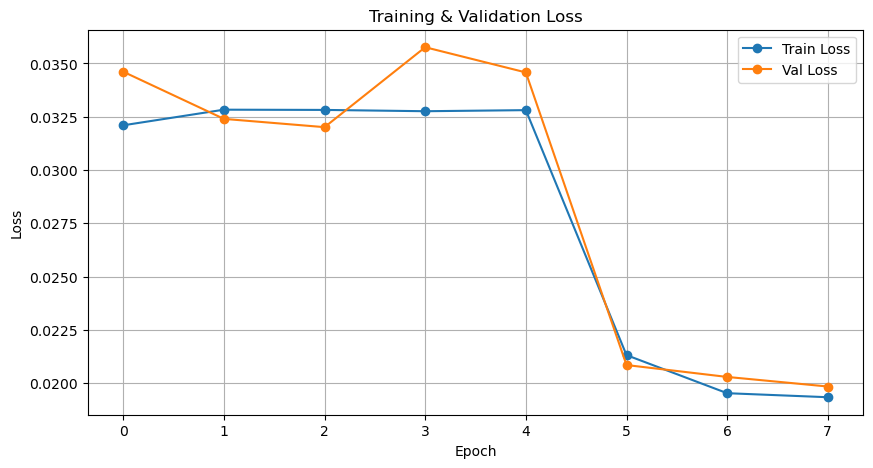


TRUE INGREDIENTS                                   | MODEL DETECTED
----------------------------------------------------------------------------------------------------
['salt', 'butter', 'garlic powder', 'dill weed',   | ['salt', 'dill']
['onion', 'butter', 'garlic', 'all purpose flour   | ['salt', 'dijon mustard', 'dill']
['salt', 'onion', 'garlic', 'tomato', 'ginger',    | ['salt', 'dill', 'sesame oil']
['onion', 'butter', 'cream cheese', 'garlic powd   | ['dill', 'sesame oil']
['onion', 'garlic', 'olive oil', 'milk', 'pepper   | ['salt', 'garlic', 'dijon mustard', 'black olive', 'rosemary', 'chive', 'dill', 'vodka', 'dill weed', 'tomatoes and green chily']
['black pepper', 'garlic powder', 'soy sauce', '   | ['garlic', 'oregano', 'dijon mustard', 'shrimp', 'black olive', 'cucumber', 'chive', 'dill', 'vodka', 'dill weed', 'thyme leaf', 'lemon peel', 'penne pasta', 'beef stew meat', 'tomatoes and green chily', 'mushrooms drained', 'cheddar', 'freshly ginger', 'red curry powder']
['s

In [16]:

# Plot loss curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()


idx_to_ing = {v: k for k, v in vocab.items()}
show_test_results(resnet, test_loader, idx_to_ing, num_images=10, threshold=0.35)

## Evaluation 

In [17]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
model = models.resnet50(weights=None) 


model.fc = nn.Linear(model.fc.in_features, len(vocab)) 


checkpoint = torch.load('best_ingredient_model.pth')
model.load_state_dict(checkpoint['state_dict'])
model.eval()
model.to(device)

all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        # Convert logits to probabilities, then to binary (0/1)
        # Using 0.5 as a standard threshold
        preds = (torch.sigmoid(outputs) > 0.35).cpu().numpy()
        
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())


y_true = np.vstack(all_labels)
y_pred = np.vstack(all_preds)


precision = precision_score(y_true, y_pred, average='samples', zero_division=0)
recall = recall_score(y_true, y_pred, average='samples', zero_division=0)
f1 = f1_score(y_true, y_pred, average='samples', zero_division=0)

print(f"--- Final Evaluation (Per-Recipe Average) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

--- Final Evaluation (Per-Recipe Average) ---
Precision: 0.0703
Recall:    0.0126
F1 Score:  0.0193


In [19]:
from sklearn.metrics import jaccard_score

model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Binary predictions (using your best threshold, e.g., 0.5)
        preds = (torch.sigmoid(outputs) > 0.3).cpu().numpy()
        test_preds.append(preds)
        test_labels.append(labels.cpu().numpy())

y_test_true = np.vstack(test_labels)
y_test_pred = np.vstack(test_preds)

# Calculate the final Jaccard (Semantic Similarity)
final_test_jaccard = jaccard_score(y_test_true, y_test_pred, average='samples')
print(f"Final Test Jaccard Similarity: {final_test_jaccard:.4f}")

Final Test Jaccard Similarity: 0.0399


/sw/pkgs/arc/python3.11-anaconda/2024.02-1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in samples with no true or predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [20]:
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

model.eval()
all_similarities = []

print("Calculating Cosine Similarity for the Test Set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float() 
        
       
        logits = model(images)
        probs = torch.sigmoid(logits)
        
      
        batch_sim = F.cosine_similarity(labels, probs, dim=1)
        
        all_similarities.extend(batch_sim.cpu().numpy())

avg_cosine_sim = np.mean(all_similarities)

print("-" * 30)
print(f"FINAL TEST SET RESULTS")
print("-" * 30)
print(f"Avg Cosine Similarity: {avg_cosine_sim:.4f}")

Calculating Cosine Similarity for the Test Set...
------------------------------
FINAL TEST SET RESULTS
------------------------------
Avg Cosine Similarity: 0.2196


The low F1 Score (0.0193) and Recall (0.0126) suggest that the model  struggles to distinguish specific ingredients, likely due to the extreme complexity and variety of the iamges in the  dataset. While the Avg Cosine Similarity (0.2196) indicates the model is beginning to align image and text features in the embedding space, the low Jaccard Similarity (0.0399) confirms that the actual overlap between predicted and ground-truth sets remains minimal. The Precision (0.0703), though higher than recall, still reflects a significant amount of noise in the top-ranked predictions. Overall, these metrics indicate that while the ResNet-50 backbone is capturing some high-level features, the current loss configuration has yet to bridge the gap between visual traits and precise recipe retrieval.